In [1]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

In [2]:
DATASET_PATH = '../dataset/processed_datasets'

In [3]:
for label in os.listdir(DATASET_PATH):
    folder = os.path.join(DATASET_PATH, label)
    print(label, ":", len(os.listdir(folder)), "files")

distress : 916 files
normal : 559 files
panic : 239 files


Load one audio file

In [4]:
sample_file = None

for label in os.listdir(DATASET_PATH):
    folder = os.path.join(DATASET_PATH, label)
    sample_file = os.path.join(folder, os.listdir(folder)[0])
    break

audio, sr = librosa.load(sample_file, sr=16000)

print("Sample Rate:", sr)
print("Audio Shape:", audio.shape)

Sample Rate: 16000
Audio Shape: (61395,)


Plot Audio Waveform

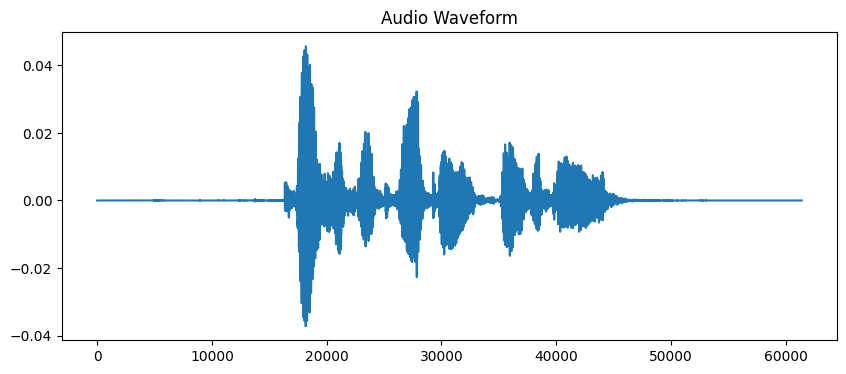

In [5]:
plt.figure(figsize=(10,4))
plt.plot(audio)
plt.title("Audio Waveform")
plt.show()

Extract MFCC

In [6]:
mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

print("MFCC Shape:", mfcc.shape)

MFCC Shape: (40, 120)


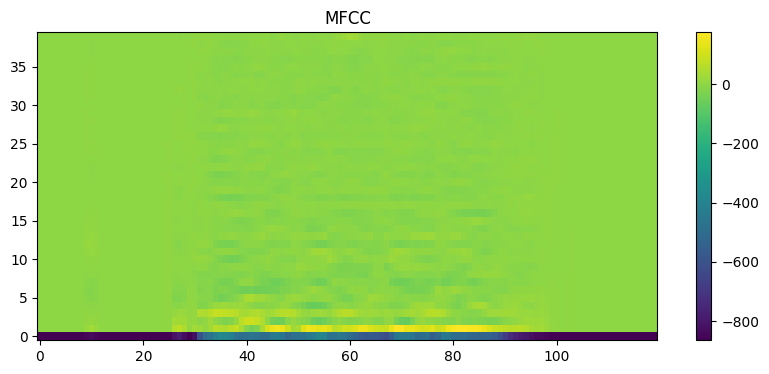

In [7]:
plt.figure(figsize=(10,4))
plt.imshow(mfcc, aspect='auto', origin='lower')
plt.title("MFCC")
plt.colorbar()
plt.show()

In [8]:
def extract_features(file_path):
    audio, sr = librosa.load(file_path, sr=16000)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    mfcc = np.mean(mfcc.T, axis=0)
    return mfcc

In [9]:
features = []
labels = []

for label in os.listdir(DATASET_PATH):
    folder = os.path.join(DATASET_PATH, label)
    
    for file in os.listdir(folder):
        file_path = os.path.join(folder, file)
        
        try:
            feature = extract_features(file_path)
            features.append(feature)
            labels.append(label)
        except:
            print("Error:", file_path)

X = np.array(features)
y = np.array(labels)

print("Dataset Loaded")
print("X shape:", X.shape)
print("y shape:", y.shape)

Dataset Loaded
X shape: (1714, 40)
y shape: (1714,)


In [10]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

y_categorical = to_categorical(y_encoded)

print("Classes:", encoder.classes_)

Classes: ['distress' 'normal' 'panic']


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42
)

In [12]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1, 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1, 1)

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32, (3,1), activation='relu', input_shape=(40,1,1)))
model.add(MaxPooling2D((2,1)))

model.add(Conv2D(64, (3,1), activation='relu'))
model.add(MaxPooling2D((2,1)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(3, activation='softmax'))

c:\Users\Rajdeep Chakraborty\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,   # small for testing
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4296 - loss: 2.9843 - val_accuracy: 0.5219 - val_loss: 1.1067
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5018 - loss: 1.0555 - val_accuracy: 0.5481 - val_loss: 0.9206
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5507 - loss: 0.9342 - val_accuracy: 0.5569 - val_loss: 0.9217
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5704 - loss: 0.9065 - val_accuracy: 0.5481 - val_loss: 0.9040
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5821 - loss: 0.8879 - val_accuracy: 0.5598 - val_loss: 0.8944
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5551 - loss: 0.8964 - val_accuracy: 0.5364 - val_loss: 0.9252
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6003 - loss: 0.8772 - val_accuracy: 0.5831 - val_loss: 0.8869
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6047 - loss: 0.8494 - val_accuracy: 0.5831 - val_loss:

In [16]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6152 - loss: 0.8425 
Accuracy: 0.615160346031189


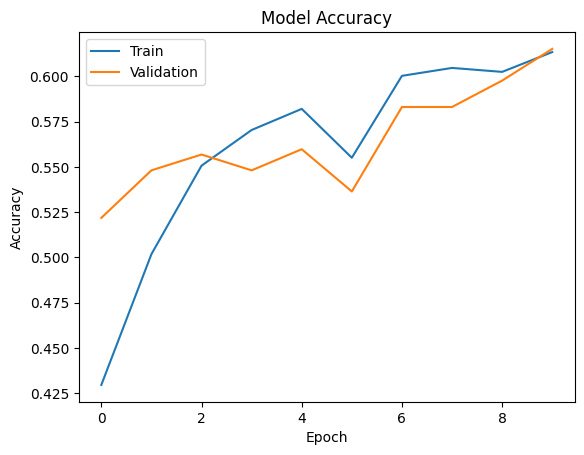

In [17]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

In [18]:
def predict(file_path):
    feature = extract_features(file_path)
    feature = feature.reshape(1,40,1,1)

    pred = model.predict(feature)
    label = encoder.inverse_transform([np.argmax(pred)])

    return label[0]

print(predict(sample_file))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
normal


In [19]:
path = "C:\\Users\\Rajdeep Chakraborty\\OneDrive\\Desktop\\JISTECH\\VoiceSecure\\dataset\\processed_datasets\\panic\\03-01-06-01-01-01-01.wav"
def predict(path):
    feature = extract_features(path)
    feature = feature.reshape(1,40,1,1)

    pred = model.predict(feature)
    label = encoder.inverse_transform([np.argmax(pred)])

    return label[0]

print(predict(sample_file))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
normal
